# Seurat label transfer from gut atlas to Xenium  > midplex
- Following 10x vignette here: https://www.10xgenomics.com/analysis-guides/xenium-cell-type-annotation
- Compare midplex to v1 and 5k

In [1]:
library(Seurat)
library(BPCells)
library(SeuratObject)
library(SeuratDisk)
library(tidyverse)
library(jsonlite)
options(future.globals.maxSize = 1e9)




Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Registered S3 method overwritten by 'SeuratDisk':
  method            from  
  as.sparse.H5Group Seurat

Warning message:
“Your system is mis-configured: ‘/var/db/timezone/localtime’ is not a symlink”
Warning message:
“‘/var/db/timezone/localtime’ is not identical to any known timezone file”
Warning message:
“Failed to locate timezone database”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r

In [2]:
library(SingleCellExperiment)

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count


The following objects are masked from ‘package:BPCells’:

    colMaxs, colQuantiles, colVars, rowMaxs, rowQuantiles, rowVars



Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, r

In [3]:
# For plotting
library(ggplot2)
library(ggpmisc)
library(scales)
library(cowplot)
library(gridExtra)
library(viridis)
library(hrbrthemes)

Loading required package: ggpp

Registered S3 methods overwritten by 'ggpp':
  method                  from   
  heightDetails.titleGrob ggplot2
  widthDetails.titleGrob  ggplot2


Attaching package: ‘ggpp’


The following object is masked from ‘package:ggplot2’:

    annotate



Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor



Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp



Attaching package: ‘gridExtra’


The following object is masked from ‘package:Biobase’:

    combine


The following object is masked from ‘package:BiocGenerics’:

    combine


The following object is masked from ‘package:dplyr’:

    combine


Loading required package: viridisLite


Attaching package: ‘viridis’


The following object is masked from ‘package:scales’:

    viridis_pal




## File info

In [4]:
out_dir <- "/home/workspace/tissue_immune_atlas_outputs/midplex_panel/midplex_pilot/ileum/seurat/TIS08925"

if (!dir.exists(out_dir)) {
  dir.create(out_dir, recursive = TRUE)
}


## Load reference reference


In [5]:
ref_dir <- '/home/workspace/data/temp/references/gut_atlas/'
ref <- readRDS(file.path(ref_dir, '1_Healthy_Pan-GI_atlas_all_lineages_20241119.rds'))

In [6]:
ref <- subset(ref, subset = organ_groups == "Small_intestine")

group_counts_df <- as.data.frame(table(ref$level_2_annot))
colnames(group_counts_df) <- c("group", "count")

low_count_groups <- group_counts_df$group[group_counts_df$count < 1000]
print(paste("removing", paste(low_count_groups, collapse=", ")))

keep <- !(ref$level_2_annot %in% low_count_groups)
# ref <- subset(ref, subset = !(level_2_annot %in% low_count_groups))
ref  <- subset(ref, cells = colnames(ref)[keep])

rna_assay <- ref[["RNA"]]
head(rna_assay@meta.features)

ref <- subset(ref, subset = nCounts_RNA > 500)

[1] "removing Cycling_T/NK, Cycling_endothelia, Erythrocyte, Granulocyte, Immature_B, Intestinal_Cajal_cell, Megakaryocyte/platelet, Microfold"


,gene_ids
,<chr>
MIR1302-2HG,ENSG00000243485
FAM138A,ENSG00000237613
OR4F5,ENSG00000186092
AL627309.1,ENSG00000238009
AL627309.3,ENSG00000239945
AL627309.2,ENSG00000239906


### BP cells for ref counts matrix

In [8]:
# # Assign a path to store the count matrix
# counts_dir <- file.path(ref_dir, "counts_bpcells/")

# # If the directory already exists, delete it to allow overwriting
# if (dir.exists(counts_dir)) {
#   unlink(counts_dir, recursive = TRUE)
# }

# # Write the counts matrix to this directory
# write_matrix_dir(mat = ref[["RNA"]]$counts, dir = counts_dir)

# # Open the on-disk counts matrix and assign to the counts layer of the Seurat object.
# counts.mat <- open_matrix_dir(dir = counts_dir)
# ref[['RNA']]$counts <- counts.mat

# rm(counts.mat)

In [9]:
ref

An object of class Seurat 
36390 features across 398389 samples within 1 assay 
Active assay: RNA (36390 features, 0 variable features)
 2 layers present: counts, data
 3 dimensional reductions calculated: scANVI, scvi, umap

## Load Xenium 

In [10]:
# Loading from Xenium outputs now
xen_dir <- "/home/workspace/data/temp/midplex_pilot/output-XETG00195__0045311__TIS08925-002-006__20250807__174200"
xenium.obj <- LoadXenium(xen_dir, fov = "fov", molecule.coordinates = FALSE)
DefaultAssay(xenium.obj) <- "Xenium"

Genome matrix has multiple modalities, returning a list of matrices for this genome

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


In [11]:
xenium.obj

An object of class Seurat 
13977 features across 305262 samples within 5 assays 
Active assay: Xenium (1570 features, 0 variable features)
 1 layer present: counts
 4 other assays present: BlankCodeword, ControlCodeword, ControlProbe, GenomicControl
 1 spatial field of view present: fov

## Process xenium

### BP cells

In [12]:
# Assign a path to store the count matrix
counts_dir <- file.path(xen_dir, "counts_bpcells/")

# If the directory already exists, delete it to allow overwriting
if (dir.exists(counts_dir)) {
  unlink(counts_dir, recursive = TRUE)
}

# Write the counts matrix to this directory
write_matrix_dir(mat = xenium.obj[["Xenium"]]$counts, dir = counts_dir)

# Open the on-disk counts matrix and assign to the counts layer of the Seurat object.
counts.mat <- open_matrix_dir(dir = counts_dir)
xenium.obj[['Xenium']]$counts <- counts.mat

rm(counts.mat)

1570 x 305262 IterableMatrix object with class MatrixDir

Row names: A1BG, A2M ... ZWINT
Col names: aaaaeham-1, aaaahcfh-1 ... oiobppdd-1

Data type: double
Storage order: column major

Queued Operations:
1. Load compressed matrix from directory /home/workspace/data/temp/midplex_pilot/output-XETG00195__0045311__TIS08925-002-006__20250807__174200/counts_bpcells

### Xenium QC

[1] 163
[1] 90


Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”
Warning message:
“Default search for "data" layer in "Xenium" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


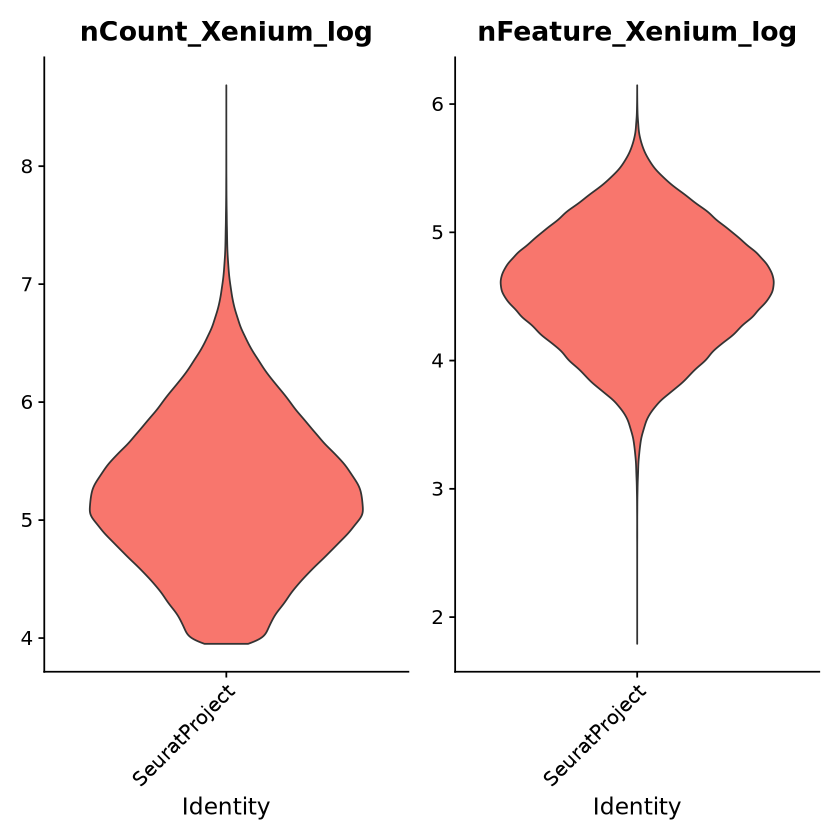

In [13]:
# What is the median tx and gene counts per cell?
print(median(xenium.obj@meta.data$nCount_Xenium))
print(median(xenium.obj@meta.data$nFeature_Xenium))

# Add log1p_nCount_RNA, log1p_nFeatures
xenium.obj@meta.data$nCount_Xenium_log <- log1p(xenium.obj@meta.data$nCount_Xenium)
xenium.obj@meta.data$nFeature_Xenium_log <- log1p(xenium.obj@meta.data$nFeature_Xenium)

# remove cells with < 50 counts (aggressive filter)
xenium.obj <- subset(xenium.obj, subset = nCount_Xenium > 50)

# Violinplots of the transcript and feature counts per cell
VlnPlot(xenium.obj, features = c("nCount_Xenium_log", "nFeature_Xenium_log"), ncol = 2, pt.size = 0, group.by = "orig.ident")

In [14]:
# This function takes in the Xenium and single cell reference Seurat object and returns the per-gene expression means

get_gex_means <- function(xenium_obj, ref_obj){

    xen_means <- data.frame(
        mean_counts = rowMeans(xenium_obj[["Xenium"]]$counts),
        gene = rownames(xenium_obj[["Xenium"]]$counts)
    ) %>%
        arrange(desc(mean_counts)) %>%
        mutate(Rank = 1:n())

    ref_means <- data.frame(
        mean_counts = rowMeans(ref_obj[["RNA"]]$counts),
        gene = rownames(ref_obj[["RNA"]]$counts)
    ) %>%
        arrange(desc(mean_counts)) %>%
        mutate(Rank = 1:n())

    # Merge mean counts per cell,
    merged_means <- merge(xen_means, ref_means, by.x = "gene", by.y = "gene", all.x = TRUE)

    return(merged_means)
}


In [15]:
merged_means <- get_gex_means(xenium.obj, ref)

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 11 rows containing non-finite outside the scale range
(`stat_poly_eq()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


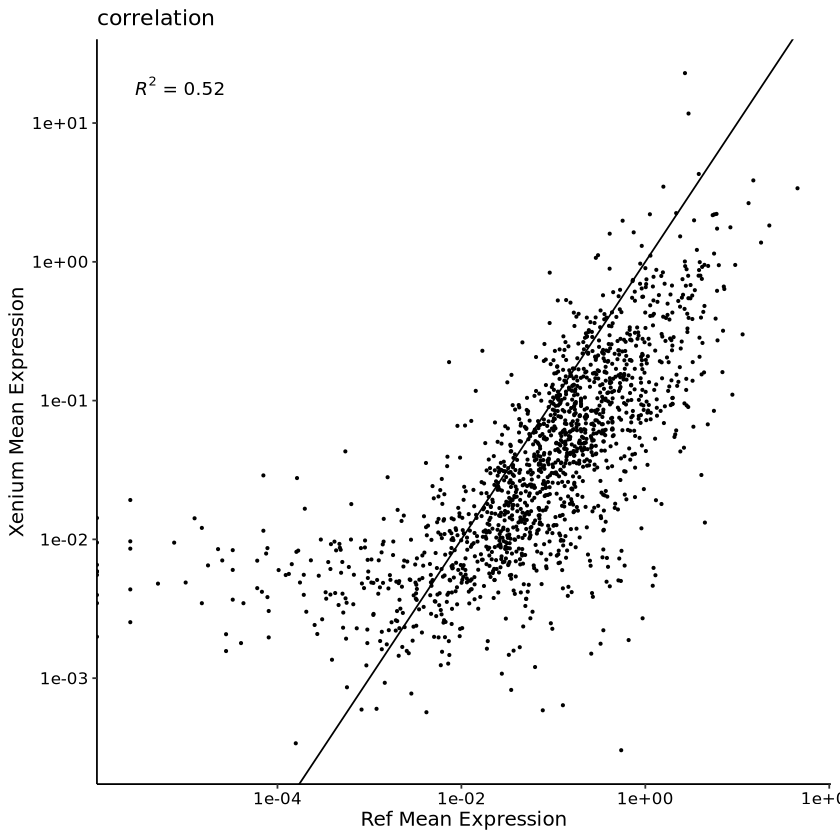

In [16]:
ggplot(merged_means, aes(x=mean_counts.y, y=mean_counts.x)) +
    geom_point(size=0.5) +
    scale_colour_manual(values=c("darkcyan", "coral")) +
    stat_poly_eq() +
    scale_x_log10() +
    scale_y_log10() +
    xlab("Ref Mean Expression") + ylab("Xenium Mean Expression") +
    ggtitle("correlation") +
    theme_classic() +
    theme(axis.text = element_text(color="black", size=10),
          axis.title = element_text(size=12)) +
    geom_abline(slope = 1, intercept = 0) 
    # tune::coord_obs_pred()

### Remove genes detected as noise in Xenium and not expressed in reference 

In [17]:
n_sd <- 2

# in this df, x is xen and y is ref

cat('genes before filtering: ', nrow(merged_means), '\n')

# first remove genes with mean counts = 0
genes_filtered <- merged_means %>% filter(mean_counts.x!=0) %>% 
filter(mean_counts.y!=0) %>%
mutate(log_diff = log10(mean_counts.x) - log10(mean_counts.y)) 

# calculate mu and sigma to identify threshold cutoff for log10 difference
mu <- mean(genes_filtered$log_diff, na.rm = TRUE)
sigma <- sd(genes_filtered$log_diff, na.rm = TRUE)
log_diff_threshold <- mu + n_sd * sigma

# filter genes > than this threshold
genes_filtered <- genes_filtered %>% filter(log_diff <log_diff_threshold)

cat('genes after filtering: ', nrow(genes_filtered))

genes before filtering:  1570 
genes after filtering:  1500

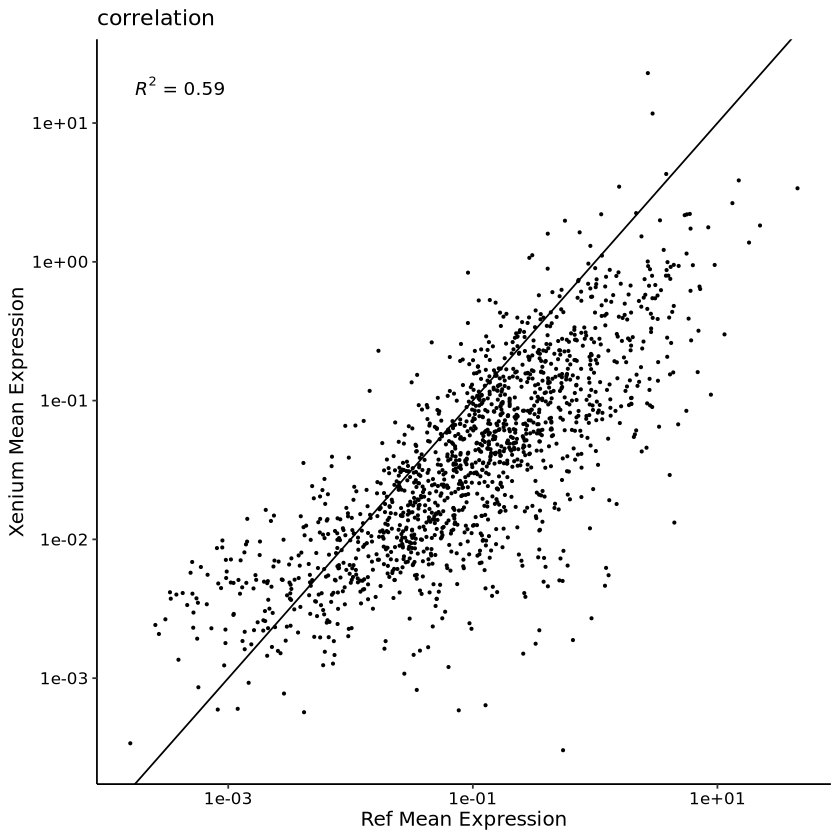

In [18]:
ggplot(genes_filtered, aes(x=mean_counts.y, y=mean_counts.x)) +
    geom_point(size=0.5) +
    scale_colour_manual(values=c("darkcyan", "coral")) +
    stat_poly_eq() +
    scale_x_log10() +
    scale_y_log10() +
    xlab("Ref Mean Expression") + ylab("Xenium Mean Expression") +
    ggtitle("correlation") +
    theme_classic() +
    theme(axis.text = element_text(color="black", size=10),
          axis.title = element_text(size=12)) +
    geom_abline(slope = 1, intercept = 0) 
    # tune::coord_obs_pred()

In [19]:
xenium.obj <- subset(xenium.obj, features = genes_filtered$gene)

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


### Normalization, umap on reference

In [20]:
DefaultAssay(ref) <- "RNA"
ref <- NormalizeData(ref) %>%
                 FindVariableFeatures() %>%
                 ScaleData() %>%
                 RunPCA() %>%
                 RunUMAP(dims=1:15) %>%
                 FindNeighbors(dims=1:15) %>%
                 FindClusters(resolution=0.5)

Warning message:
“The `slot` argument of `SetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Centering and scaling data matrix

PC_ 1 
Positive:  TUBA1A, TPM2, SPARCL1, TIMP1, IGFBP7, FLNA, COL4A1, LUM, IGFBP4, RAMP2 
	   SLC9A3R2, SRGN, CORO1A, GNG11, BASP1, ACTA2, MLLT11, CCN2, MAP1B, SYNPO2 
	   TIMP3, C11orf96, CAV1, HMGB2, FABP5, RGS1, LSP1, CD37, MYLK, TAGLN 
Negative:  FABP1, RBP2, SMIM24, EPCAM, C19orf33, ANPEP, PHGR1, FABP2, AMN, CLDN7 
	   S100A14, MTTP, APOA1, SERPINA1, LGALS3, KRT8, CDHR5, CLDN3, PRAP1, LGALS4 
	 

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 398389
Number of edges: 12060866

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9575
Number of communities: 31
Elapsed time: 339 seconds


1 singletons identified. 30 final clusters.



#### Make named colors for plotting labels consistently 

In [21]:
n_colors <- length(unique(ref$level_2_annot))
colors_polychrome <- Seurat::DiscretePalette(n = n_colors, palette = "polychrome")
names(colors_polychrome) <-unique(ref$level_2_annot)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



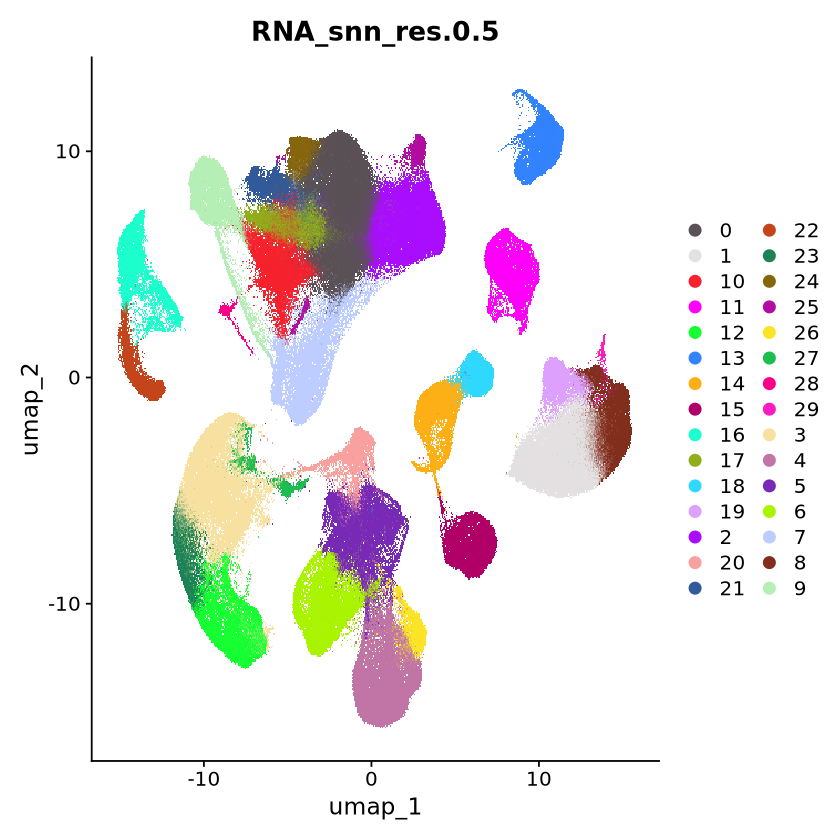

In [22]:
DimPlot(ref, reduction = "umap", cols = "polychrome", group.by = "RNA_snn_res.0.5")

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



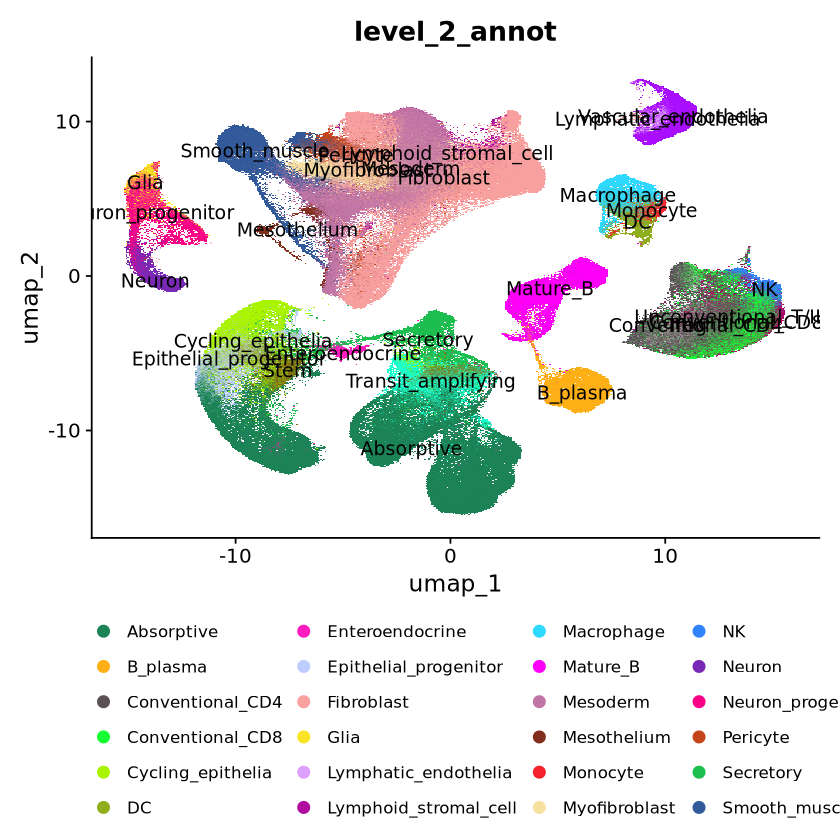

In [23]:
DimPlot(ref, reduction = "umap", 
              cols = colors_polychrome, 
        label=T,
              group.by = "level_2_annot") +
  theme(
    legend.position = "bottom",       
    legend.text = element_text(size = 10),
    legend.key.size = unit(0.5, "cm")
  )

### Normalize, umap on Xenium 

Normalizing layer: counts

Finding variable features for layer counts

Calcuating Leverage Score

Attempting to cast layer counts to dgCMatrix

Attempting to cast layer data to dgCMatrix

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  A2M, TXNIP, COL1A2, COL6A2, CD81, COL3A1, SPARC, COL1A1, COL6A1, VIM 
	   DCN, MMP2, CXCL12, LUM, MFAP4, C1R, IGFBP4, MYL9, IGFBP7, COL4A1 
	   RHOB, TGFBI, FSTL1, PDGFRB, TGFBR2, CFH, LGALS1, FN1, S100A4, ADAMDEC1 
Negative:  ANPEP, PIGR, PHGR1, KRT8, MME, ATP1B1, KRT20, APOB, ACE, FABP2 
	   HSD17B2, CCL25, KRT18, SGK1, PCSK5, ERBB3, KRT19, LGALS3, HMGCS2, CDH1 
	   VDAC1, LDHA, NDRG1, COX4I1, SAT2, SERPINA1, CYP2C18, KLF5, ATP5F1A, DMBT1 
PC_ 2 
Positive:  CXCR4, IL7R, CD3E, TRBC2, CD37, TRAC, PTPRC, CD52, CD2, LCP1 
	   IKZF1, IKZF3, CD3D, LTB, CCL5, CD79A, KLRB1, POU2AF1, CD69, CD8A 
	   MS4A1, JCHAIN, CD48, TNFRSF13C, CD247, IGHM, ITGAL, CD19, CD96, PRDM1 
Negative:  IGFBP4, GSN, TPM1, TIMP3, S100A6,

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 100000
Number of edges: 3213404

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9134
Number of communities: 21
Elapsed time: 48 seconds


1 singletons identified. 20 final clusters.



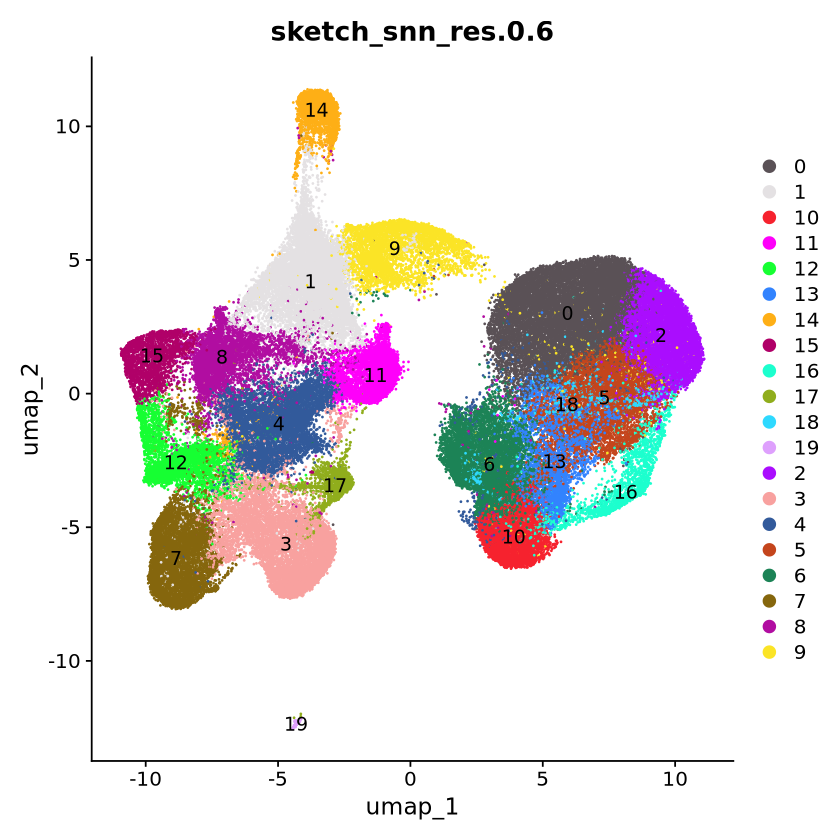

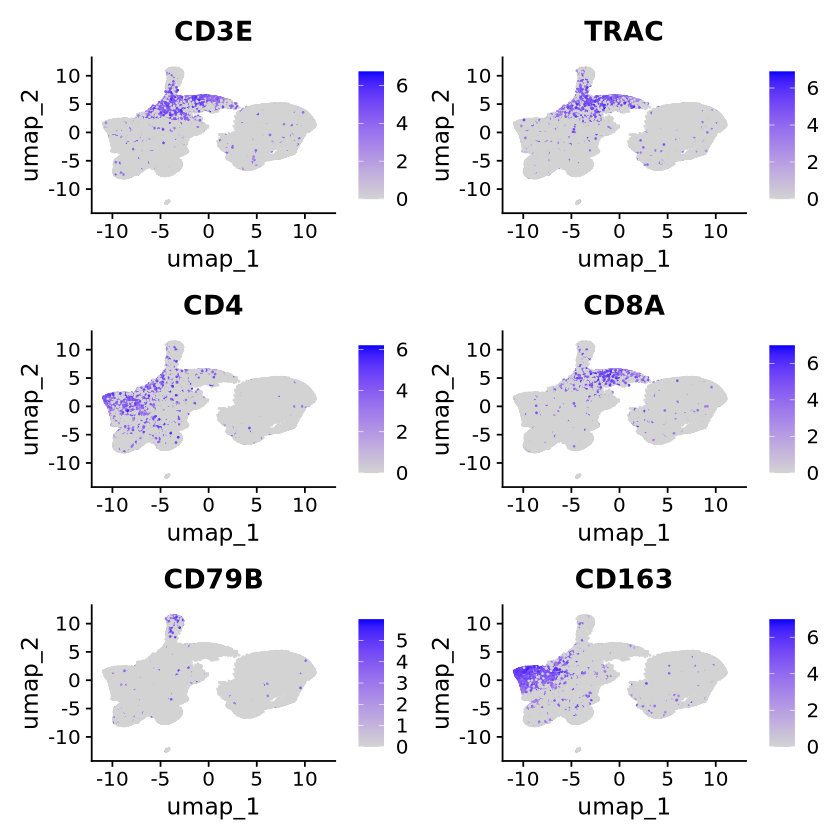

In [24]:
# xenium sketch dataset
DefaultAssay(xenium.obj) <- "Xenium"
xenium.obj <- NormalizeData(xenium.obj)
xenium.obj <- FindVariableFeatures(xenium.obj)
xenium.obj <- SketchData(
    object = xenium.obj,
    ncells = 100000,
    method = "LeverageScore",
    sketched.assay = "sketch"
)
DefaultAssay(xenium.obj) <- "sketch"

# process xenium 
xenium.obj <- FindVariableFeatures(xenium.obj) %>%
              ScaleData() %>%
              RunPCA(npcs = 20) %>%
              RunUMAP(dims = 1:16, return.model=TRUE) %>%
              FindNeighbors(reduction = "pca", dims = 1:16) %>%
              FindClusters(resolution = 0.6)

# Plot UMAP
DimPlot(xenium.obj, group.by = c("sketch_snn_res.0.6"), cols = "polychrome", label=T, label.size = 4)

markers <- c('CD3E', 'TRAC', 'CD4', 'CD8A', 'CD79B', 'CD163')
FeaturePlot(xenium.obj, features = markers)

In [25]:
xenium.obj

An object of class Seurat 
3000 features across 271069 samples within 2 assays 
Active assay: sketch (1500 features, 1500 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: Xenium
 2 dimensional reductions calculated: pca, umap
 1 spatial field of view present: fov

## Label transfer on sketch xenium

- First subset to common genes: visualize reference umap using these genes only - how well are cell types separated?
- Then run find anchors for label tranfer: Eventually we will want to consolidate some of these labels (combine the labels that do not separate well in above umap), but for now just move forward with current granularity 

[1] 1500
[1] "subset ref to common genes and process ref"


Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

17:52:10 Annoy recall = 100%

17:52:12 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

17:52:22 Initializing from normalized Laplacian + noise (using RSpectra)

17:54:17 Commencing optimization for 200 epochs, with 16832650 positive edges

17:54:17 Using rng type: pcg

17:57:28 Optimization finished

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



[1] "find anchors"


Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 47967 anchors



[1] "label transfer"


Finding integration vectors

Finding integration vector weights

Predicting cell labels



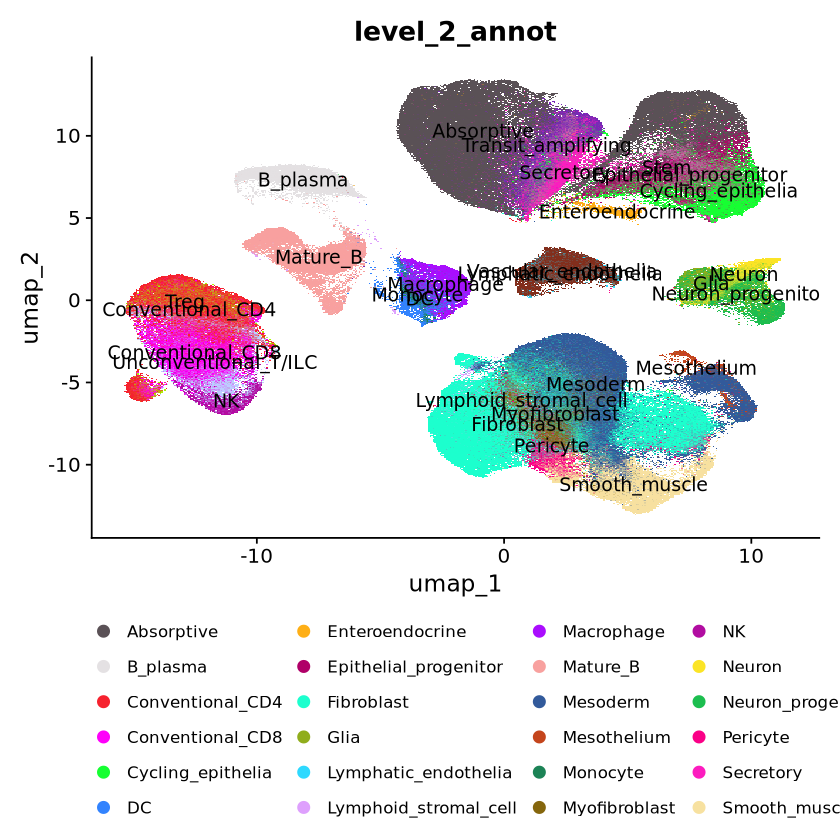

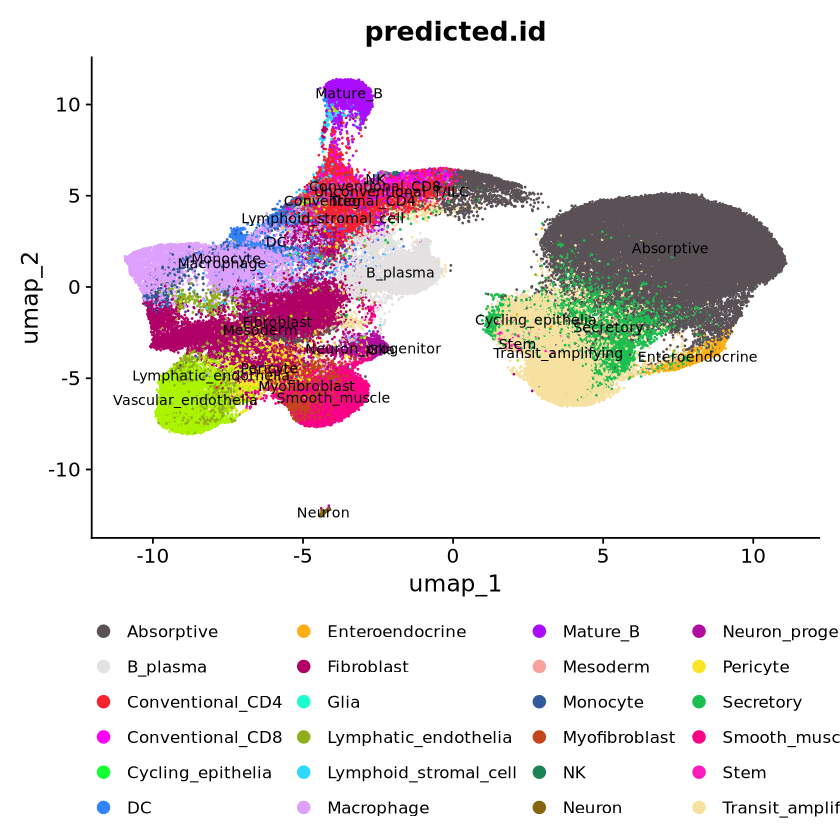

In [26]:
# Get the genes shared between the reference and query datasets
common_genes <- intersect(rownames(xenium.obj), rownames(ref))
print(length(common_genes))

# subset ref to common genes and process
print('subset ref to common genes and process ref')
ref_subset <- CreateSeuratObject(counts = ref[["RNA"]]$counts[common_genes,],
                                 meta = ref@meta.data) %>%
                                NormalizeData() %>%
                                FindVariableFeatures() %>%
                                ScaleData() %>%
                                RunPCA() %>%
                                RunUMAP(dims=1:15) 

# visualize reference subset processed
DimPlot(ref_subset, reduction = "umap", 
              # cols = colors_polychrome, 
        cols = "polychrome", 
        label=T,
              group.by = "level_2_annot") +
  theme(
    legend.position = "bottom",       
    legend.text = element_text(size = 10),
    legend.key.size = unit(0.5, "cm")
  )

# Find anchors
print('find anchors')
ref[["RNA"]]$counts <- as(object = ref[["RNA"]]$counts, Class = "dgCMatrix")

xenium.obj[["Xenium"]]$counts <- as(object = xenium.obj[["Xenium"]]$counts, Class = "dgCMatrix")

anchors_from_ref <- FindTransferAnchors(reference = ref_subset,
                                         query = xenium.obj,
                                         query.assay = "sketch",
                                         features = common_genes,
                                         dims = 1:20,
                                         reference.reduction = "pca")

# Label transfer
print('label transfer')
label_transfer <- TransferData(anchorset = anchors_from_ref,
                               refdata = ref_subset$level_2_annot,
                               dims = 1:20)

# add predicted id
xenium.obj <- AddMetaData(object = xenium.obj, metadata = label_transfer, col.name = 'predicted.id')

# visualize
DimPlot(xenium.obj, group.by = c("predicted.id"), 
        cols = "polychrome", 
        label=T, label.size = 3)+
  theme(
    legend.position = "bottom",       
    legend.text = element_text(size = 10),
    legend.key.size = unit(0.5, "cm")
  )

In [27]:
# save the xenium object after label transfer 
saveRDS(xenium.obj, file.path(out_dir, 'xenium_processed_labeltransfer_TIS08925_midplex.rds'))

## Try co-embedding the xenium and reference 

Then we can visualize the predicted labels in the co-embedding space

In [28]:
# dim reduction on combined object without integration
standard_dim_reduction <- function(obj, seed=1234){

    DefaultAssay(obj) <- "RNA"

    set.seed(seed)
    
    obj <- NormalizeData(obj)
    obj <- FindVariableFeatures(obj)
    obj <- ScaleData(obj)
    obj <- RunPCA(obj)
    
    obj <- FindNeighbors(obj, dims = 1:10, reduction = "pca") #1:30
    obj <- FindClusters(obj, resolution = 1, cluster.name = "unintegrated_clusters")
    
    obj <- RunUMAP(obj, dims = 1:10, reduction = "pca", reduction.name = "umap.unintegrated") #1:30

    return(obj)}

# dim reduction with integration
integrate_objects <- function(comb_obj, integration_method = CCAIntegration, reduction_name = 'integrated.cca', seed=1234){

    set.seed(seed)
    comb_obj <- IntegrateLayers(object = comb_obj, method = integration_method, orig.reduction = "pca", 
                                new.reduction = reduction_name,
                                verbose = FALSE)

    # print(ElbowPlot(comb_obj, reduction = "integrated.cca", ndims = 50))
    
    # re-join layers after integration
    comb_obj[["RNA"]] <- JoinLayers(comb_obj[["RNA"]])
    
    comb_obj <- FindNeighbors(comb_obj, reduction = reduction_name, dims = 1:20) # 1:30
    comb_obj <- FindClusters(comb_obj, resolution = 1)
    
    comb_obj <- RunUMAP(comb_obj, dims = 1:20, reduction = reduction_name, seed.use=seed) # 1:30
    return(comb_obj)}

########


# make subset that is just the sketch 
cells_use <- colnames(xenium.obj[["sketch"]])
length(cells_use)  # sanity check

# subset the original object to those cells
xenium_sketch <- subset(xenium.obj, cells = cells_use)
DefaultAssay(xenium_sketch) <- "Xenium"

# Keep only the RNA assay and only its counts slot - xenium
xenium_sketch_layer <- DietSeurat(
    object = xenium_sketch,
    assays = "Xenium",
    layers = "counts"
)

xenium_sketch_layer <- RenameAssays(xenium_sketch_layer, Xenium = "RNA")
xenium_sketch_layer

# Keep only the RNA assay and only its counts slot - reference
ref_subset_layer <- DietSeurat(
    object = ref_subset,
    assays = "RNA",
    layers = "counts"
)
ref_subset_layer

# make a combined object with ref and xen
ref_subset_layer$modality <- 'ref'
xenium_sketch_layer$modality <- 'xen'
comb <- merge(ref_subset_layer, y=xenium_sketch_layer)
comb

# make small subset to run the co-embedding on
downsample <- sample(colnames(comb), 100000)
comb_sub <- subset(comb, cells = downsample)

cat('Downsampled from', paste(dim(comb), collapse = "x"), 'to', paste(dim(comb_sub), collapse = "x"), '\n')

comb_sub <- standard_dim_reduction(comb_sub)
comb_sub_cca <- integrate_objects(comb_sub, integration_method = CCAIntegration, reduction_name = 'integrated.cca', seed=0001)
# comb <- standard_dim_reduction(comb)
# comb_cca <- integrate_objects(comb, integration_method = CCAIntegration, reduction_name = 'integrated.cca', seed=0001)

# save the xenium object after label transfer 
saveRDS(comb_sub_cca, file.path(out_dir, 'xenium_ref_comb_sub_TIS08925_midplex.rds'))



[1] 100000

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”
Renaming default assay from Xenium to RNA

Warning message:
“Key ‘xenium_’ taken, using ‘rna_’ instead”


An object of class Seurat 
1500 features across 1e+05 samples within 1 assay 
Active assay: RNA (1500 features, 1500 variable features)
 1 layer present: counts
 1 spatial field of view present: fov

An object of class Seurat 
1500 features across 398389 samples within 1 assay 
Active assay: RNA (1500 features, 1500 variable features)
 1 layer present: counts

Warning message:
“Adding image data that isn't associated with any assays”


...

Normalizing layer: counts.1

Normalizing layer: counts.2

Finding variable features for layer counts.1

Finding variable features for layer counts.2

Centering and scaling data matrix

PC_ 1 
Positive:  SPARC, MDK, RBP1, COL3A1, COL1A1, NREP, COL1A2, MFAP4, LGALS1, STMN1 
	   FSTL1, VCAN, COL6A2, SOX4, VIM, PTMS, COL6A1, MEST, MARCKS, TCF21 
	   TIMP1, FN1, FKBP10, DCN, TSHZ2, TCF4, MMP2, CCN1, NFIA, TUBA1A 
Negative:  CD52, PTPRC, CD74, SRGN, IL32, CD37, CD69, CD48, CD3D, CD3E 
	   CXCR4, RGS1, TRBC2, TRAC, IL7R, IL2RG, CCL5, LTB, LCP1, KLRB1 
	   FYB1, CD2, CD7, ISG20, NEAT1, BIRC3, IKZF1, CRIP1, CD3G, ALOX5AP 
PC_ 2 
Positive:  KRT8, EPCAM, PHGR1, LGALS3, KRT18, SPINK1, FABP2, ANPEP, SERPINA1, KRT19 
	   KLF5, CCL25, LGALS2, MGST1, CDH1, ERBB3, APOB, MT1F, HSD17B2, PERP 
	   RBM47, CCL15, NDRG1, ATP1B1, GATA6, TTR, SLC2A2, CEBPA, HEBP1, TSPAN13 
Negative:  VIM, CD52, LGALS1, CXCR4, PTPRC, CD69, IFITM2, SRGN, CD37, COL1A2 
	   CD3D, RGS1, COL3A1, CD3E, CD48, TRBC2, TRAC, COL6A2, COL1

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 100000
Number of edges: 3168931

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9188
Number of communities: 34
Elapsed time: 42 seconds


18:08:58 UMAP embedding parameters a = 0.9922 b = 1.112

18:08:58 Read 100000 rows and found 10 numeric columns

18:08:58 Using Annoy for neighbor search, n_neighbors = 30

18:08:58 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18:09:07 Writing NN index file to temp file /tmp/RtmpPMmfmJ/file3333c5aa3ea

18:09:07 Searching Annoy index using 1 thread, search_k = 3000

18:09:48 Annoy recall = 100%

18:09:49 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

18:09:54 Initializing from normalized Laplacian + noise (using RSpectra)

18:10:07 Commencing optimization for 200 epochs, with 4058526 positive edges

18:10:07 Using rng type: pcg

18:10:51 Optimization finished

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 100000
Number of edges: 3393663

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9136
Number of communities: 36
Elapsed time: 35 seconds


18:14:37 UMAP embedding parameters a = 0.9922 b = 1.112

18:14:37 Read 100000 rows and found 20 numeric columns

18:14:37 Using Annoy for neighbor search, n_neighbors = 30

18:14:37 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18:14:46 Writing NN index file to temp file /tmp/RtmpPMmfmJ/file3331cbef4e2

18:14:46 Searching Annoy index using 1 thread, search_k = 3000

18:15:25 Annoy recall = 100%

18:15:26 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

18:15:31 Initializing from normalized Laplacian + noise (using RSpectra)

18:15:39 Commencing optimization for 200 epochs, with 4283352 positive edges

18:15:39 Using rng type: pcg

18:16:24 Optimization finished



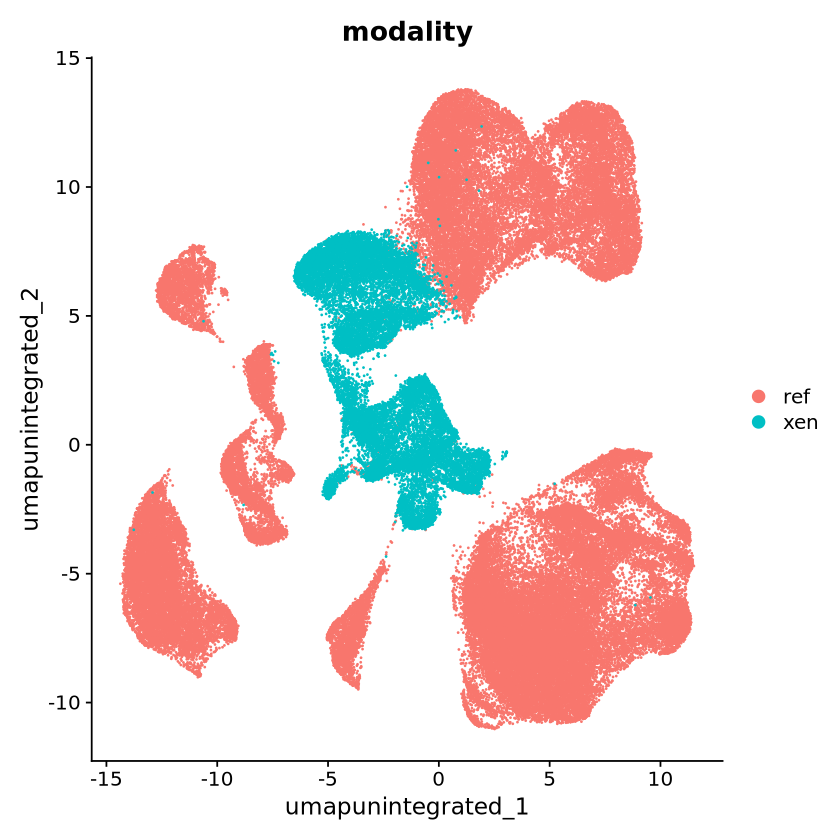

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Adding image data that isn't associated with any assays”
Warning message:
“Not validating Seurat objects”


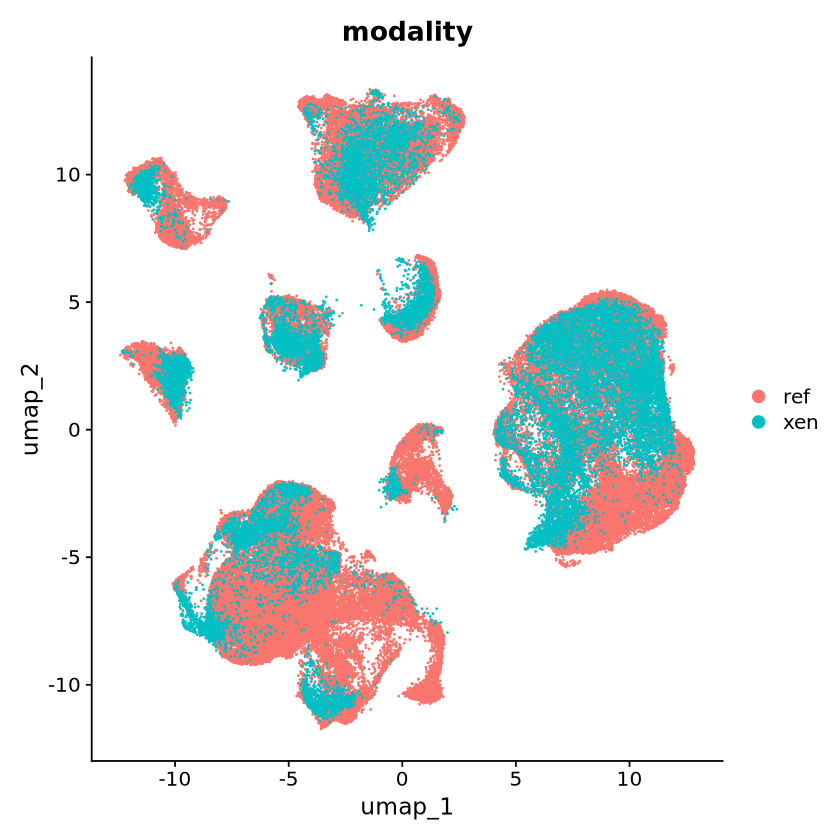

Warning message:
“Not validating Seurat objects”


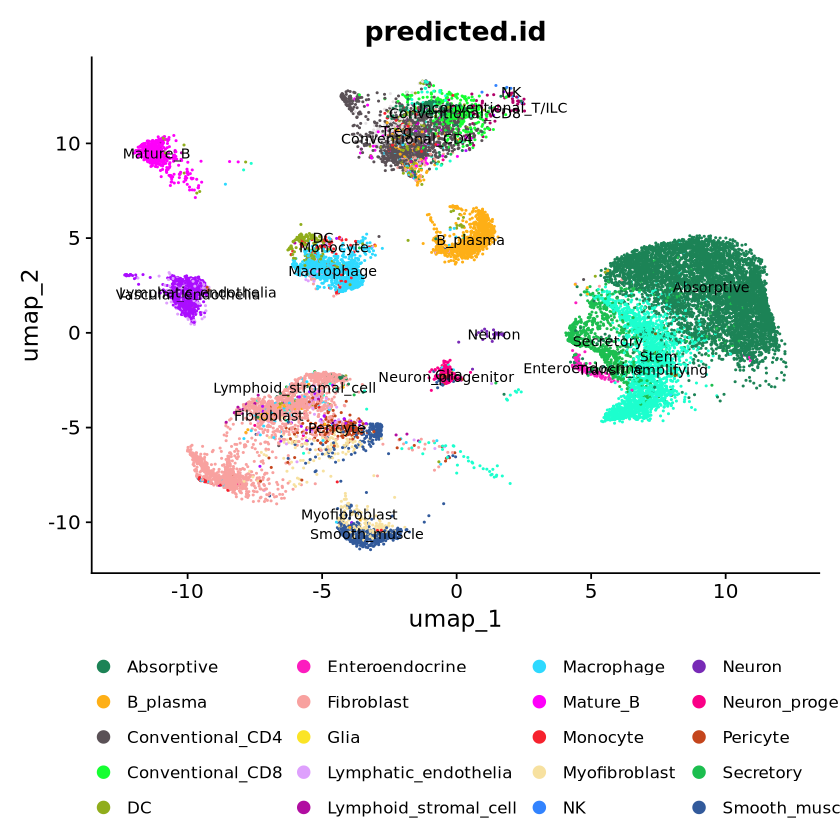

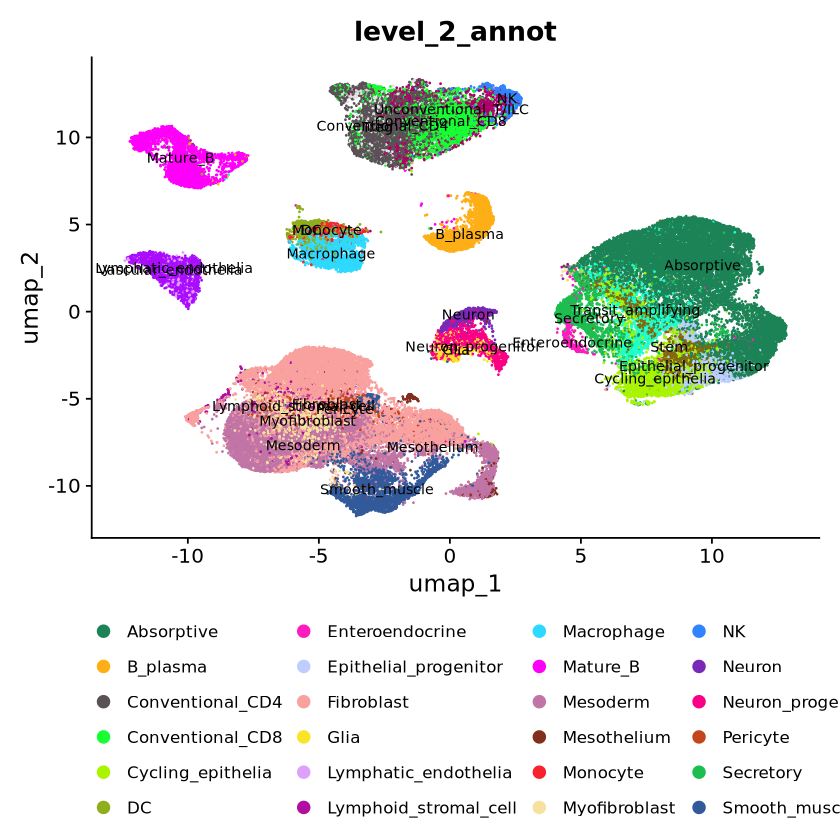

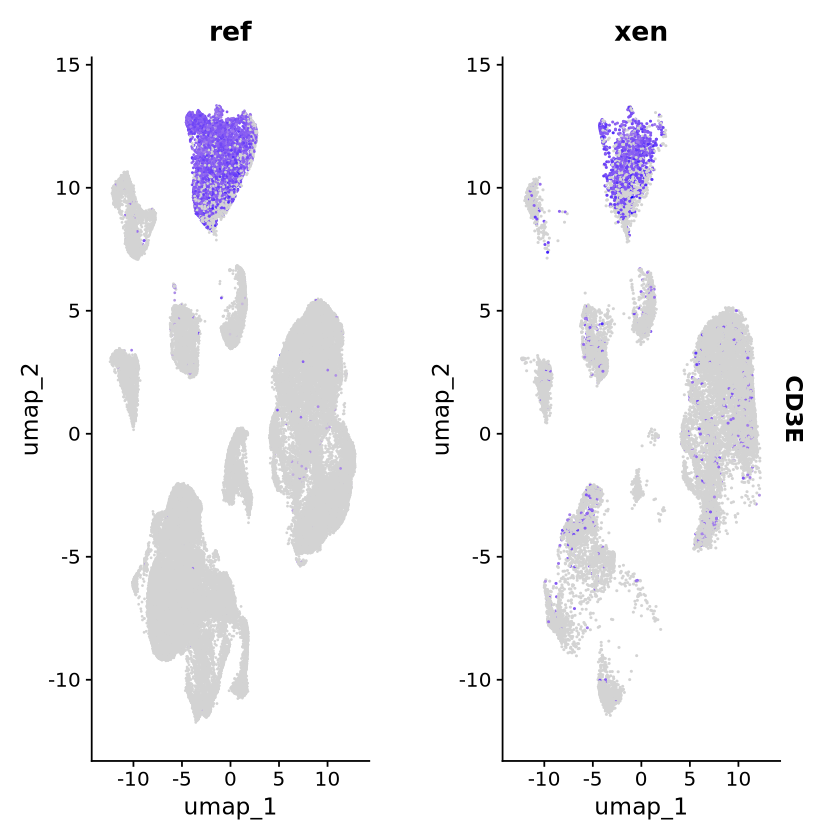

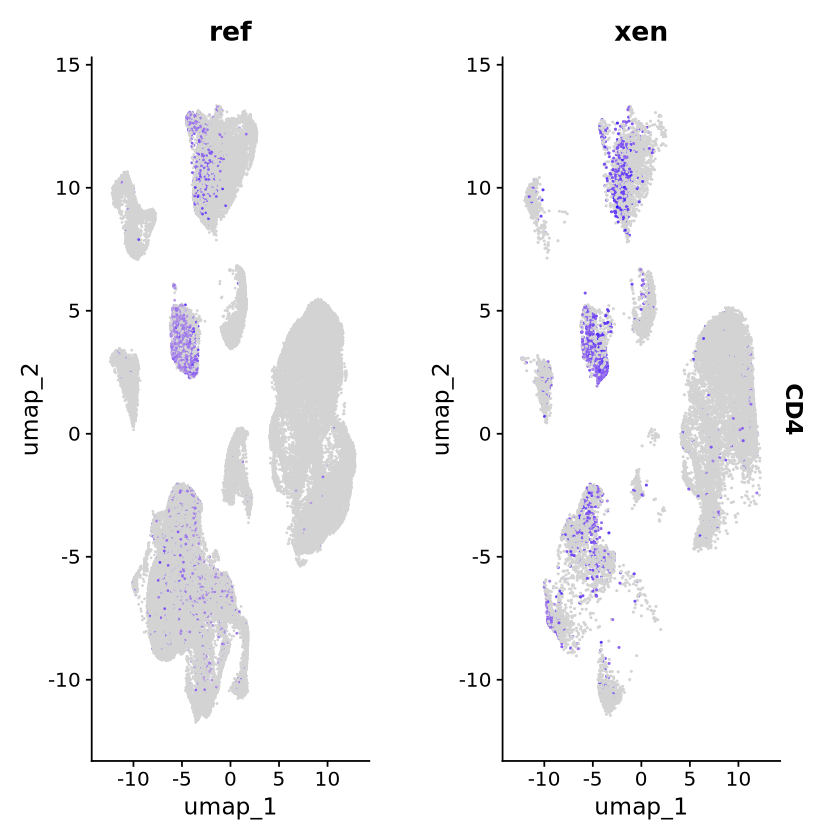

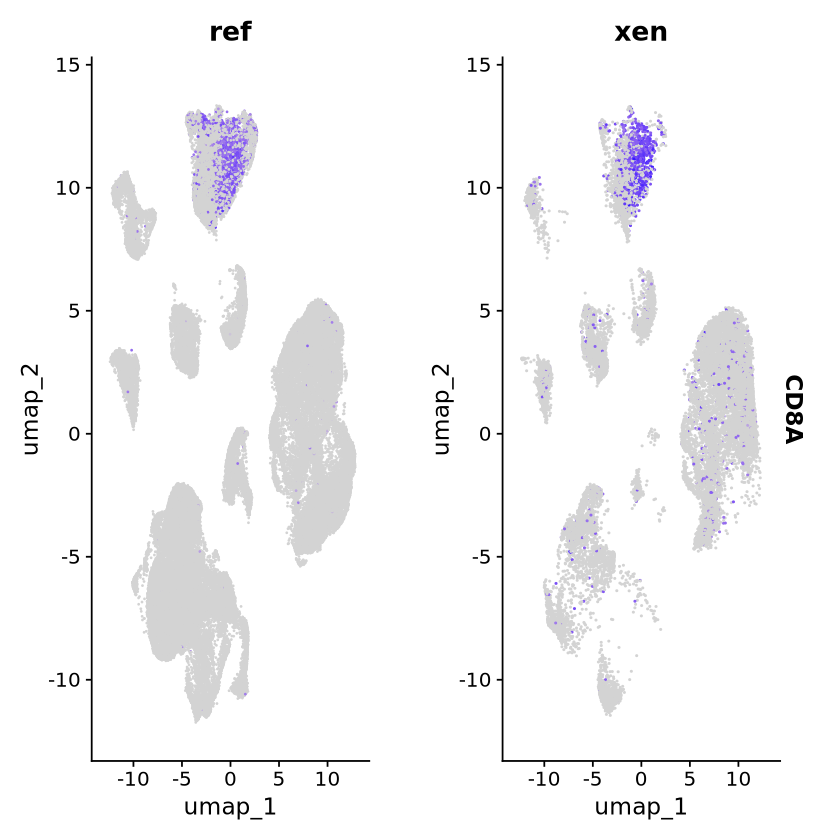

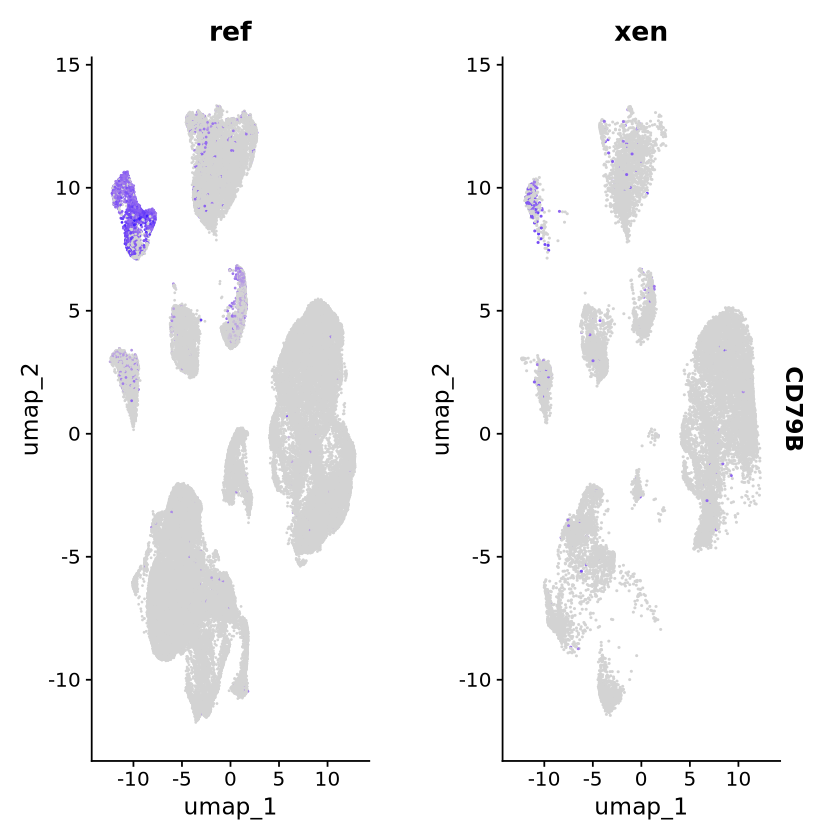

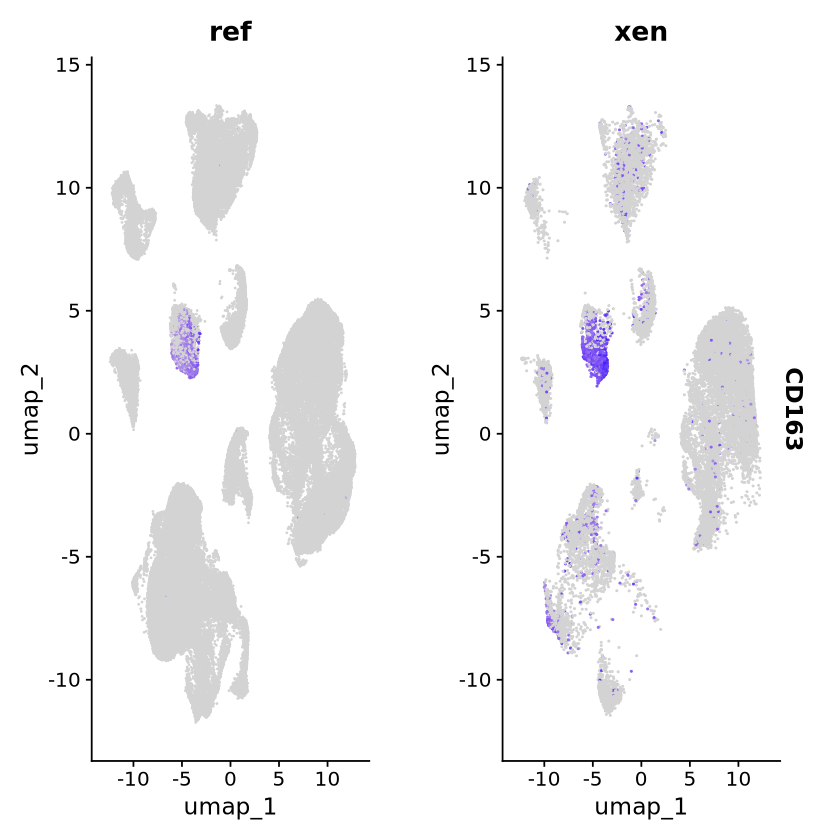

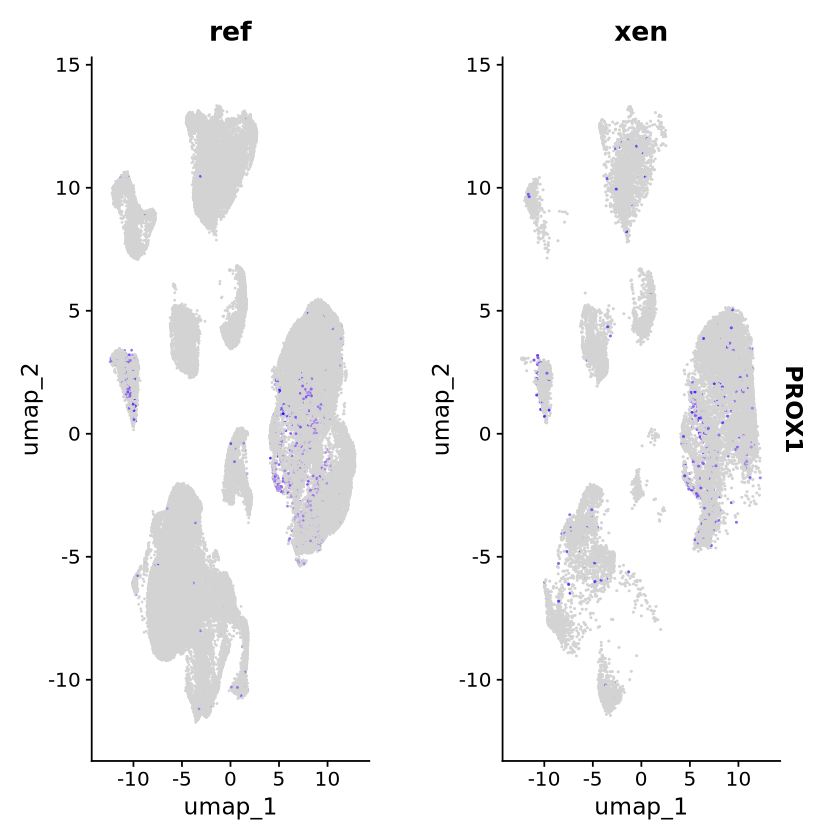

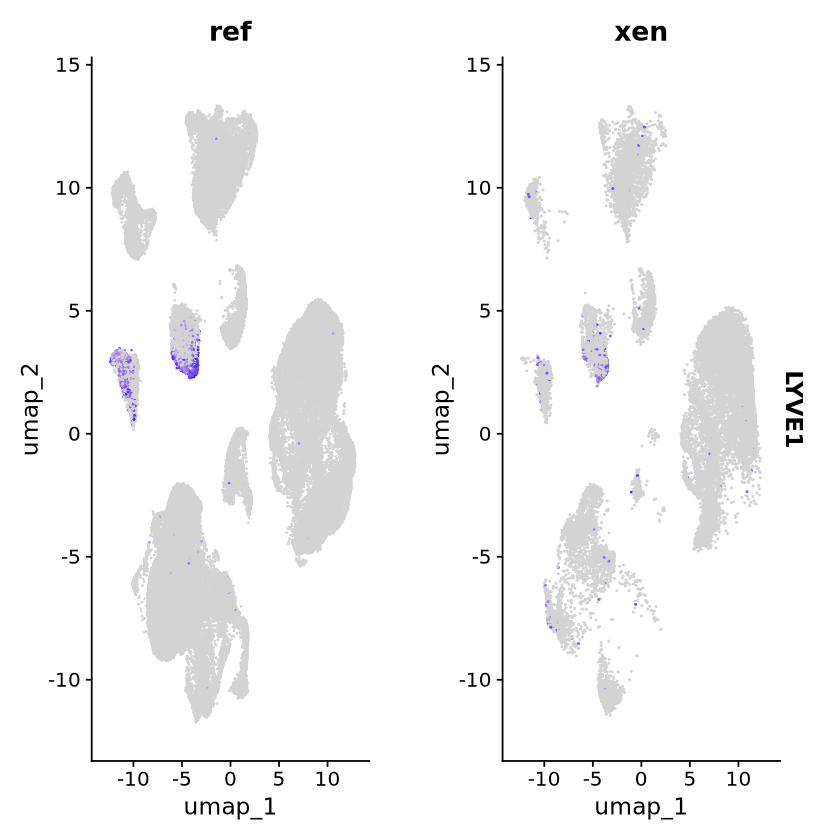

In [29]:
# visualize
DimPlot(comb_sub, reduction = "umap.unintegrated", group.by = "modality")
DimPlot(comb_sub_cca, reduction = "umap", group.by = "modality")

DimPlot(subset(comb_sub_cca, modality=="xen"), 
        reduction = "umap", group.by = "predicted.id", 
        # split.by = "modality", 
         label=T, label.size = 3,
        cols = colors_polychrome) +
  theme(
    legend.position = "bottom",       
    legend.text = element_text(size = 10),
    legend.key.size = unit(0.5, "cm")
  )

DimPlot(subset(comb_sub_cca, modality=="ref"), 
        reduction = "umap", group.by = "level_2_annot", 
        # split.by = "modality", 
         label=T, label.size = 3,
        cols = colors_polychrome) +
  theme(
    legend.position = "bottom",       
    legend.text = element_text(size = 10),
    legend.key.size = unit(0.5, "cm")
  )


markers <- c('CD3E',  'CD4', 'CD8A', 'CD79B', 'CD163', 'PROX1', 'LYVE1')
for (marker in markers){
    print(FeaturePlot(comb_sub_cca, features = marker, reduction = "umap", split.by = "modality"))}

In [30]:
write.csv(label_transfer, file = file.path(out_dir, "label_transfer_midplex.csv"), row.names = TRUE)



In [31]:
label_transfer

,predicted.id,prediction.score.Conventional_CD4,prediction.score.Treg,prediction.score.Monocyte,prediction.score.Mature_B,prediction.score.Conventional_CD8,prediction.score.NK,prediction.score.B_plasma,prediction.score.Unconventional_T.ILC,prediction.score.Transit_amplifying,⋯,prediction.score.Secretory,prediction.score.Neuron_progenitor,prediction.score.Enteroendocrine,prediction.score.Myofibroblast,prediction.score.Mesoderm,prediction.score.Neuron,prediction.score.Cycling_epithelia,prediction.score.Epithelial_progenitor,prediction.score.Mesothelium,prediction.score.max
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
aaaajiah-1,Fibroblast,0.0000000,0.00000000,0.00000000,0,0.00000000,0.000000000,0,0.00000000,0.00000000,⋯,0,0.0000000,0,0.222237902,0.12932237,0.0000000,0,0,0.00000000,0.4577014
aaabggcm-1,Monocyte,0.0000000,0.00000000,0.94046107,0,0.00000000,0.000000000,0,0.00000000,0.00000000,⋯,0,0.0000000,0,0.000000000,0.00000000,0.0000000,0,0,0.00000000,0.9404611
aaaccphl-1,Smooth_muscle,0.0000000,0.00000000,0.00000000,0,0.00000000,0.000000000,0,0.00000000,0.00000000,⋯,0,0.0000000,0,0.000000000,0.00000000,0.0000000,0,0,0.00000000,1.0000000
aaacfipc-1,Macrophage,0.0000000,0.00000000,0.00000000,0,0.00000000,0.000000000,0,0.00000000,0.00000000,⋯,0,0.0000000,0,0.000000000,0.00000000,0.0000000,0,0,0.00000000,0.9539188
aaadepeh-1,Fibroblast,0.0000000,0.00000000,0.00000000,0,0.00000000,0.000000000,0,0.00000000,0.00000000,⋯,0,0.0000000,0,0.000000000,0.00000000,0.0000000,0,0,0.00000000,1.0000000
aaadgmci-1,Vascular_endothelia,0.0000000,0.00000000,0.00000000,0,0.00000000,0.000000000,0,0.00000000,0.00000000,⋯,0,0.0000000,0,0.000000000,0.00000000,0.0000000,0,0,0.00000000,0.4898648
aaaebnkh-1,Fibroblast,0.0000000,0.00000000,0.00000000,0,0.00000000,0.000000000,0,0.00000000,0.00000000,⋯,0,0.0000000,0,0.036019884,0.01072992,0.0000000,0,0,0.00000000,0.4682966
aaaeeffg-1,Vascular_endothelia,0.0000000,0.00000000,0.00000000,0,0.00000000,0.000000000,0,0.00000000,0.00000000,⋯,0,0.0000000,0,0.000000000,0.00000000,0.0000000,0,0,0.00000000,0.5336591
aaaehfml-1,DC,0.0000000,0.00000000,0.14539244,0,0.00000000,0.000000000,0,0.00000000,0.00000000,⋯,0,0.0000000,0,0.000000000,0.00000000,0.0000000,0,0,0.00000000,0.8311899
